
# Reto 2
## Aprendizaje Automatico
### Analisis de Crimenes

Daniel Gonzalez - 16/05/2025

# Cargar Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import geopandas as gpd
import math


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Notebooks/DB/Crimenes/actes-criminels.csv')
df.shape
df.head()

,CATEGORIE,DATE,QUART,PDQ,X,Y,LONGITUDE,LATITUDE
0,Vol de véhicule à moteur,2018-09-13,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780
1,Vol de véhicule à moteur,2018-04-30,jour,30.0,294904.159001,5.047549e+06,-73.626778,45.567780
2,Vol de véhicule à moteur,2018-09-01,nuit,7.0,290274.565000,5.042150e+06,-73.685928,45.519122
3,Méfait,2017-07-21,jour,21.0,NaN,NaN,NaN,NaN
4,Méfait,2017-07-29,jour,12.0,NaN,NaN,NaN,NaN


# 1. Analisis de los Datos

In [5]:
df = df.rename(columns={
    'CATEGORIE': 'Crime',
    'DATE': 'Date',
    'QUART': 'Shift',
    'PDQ': 'Precinct',
    'LONGITUDE': 'Longitude',
    'LATITUDE': 'Latitude'
})

In [6]:
df['Crime'] = df['Crime'].replace({
    'Vol de véhicule à moteur': 'Motor vehicle theft',
    'Méfait': 'Mischief',
    'Vols qualifiés': 'Armed robbery',
    'Vol dans / sur véhicule à moteur': 'Theft from motor vehicle',
    'Introduction': 'Breaking and entering',
    'Infractions entrainant la mort': 'Offences leading to death'
})

In [7]:
df['Shift'] = df['Shift'].replace({
    'jour': 'day',
    'nuit': 'night',
    'soir': 'afternon'
})

In [8]:
df['Precinct'] = pd.to_numeric(df['Precinct'], errors='coerce').astype('Int64')

In [9]:
for c in df.columns:
    null_count = np.sum(pd.isnull(df[c]))  # Contar valores nulos
    data_types = df[c].dropna().apply(type).unique()  # Obtener tipos de datos únicos sin NaN
    print(f'Column: {c} - Nulls: {null_count} - Data Types: {data_types}')

Column: Crime - Nulls: 0 - Data Types: [<class 'str'>]
Column: Date - Nulls: 0 - Data Types: [<class 'str'>]
Column: Shift - Nulls: 0 - Data Types: [<class 'str'>]
Column: Precinct - Nulls: 5 - Data Types: [<class 'int'>]
Column: X - Nulls: 41393 - Data Types: [<class 'float'>]
Column: Y - Nulls: 41393 - Data Types: [<class 'float'>]
Column: Longitude - Nulls: 41393 - Data Types: [<class 'float'>]
Column: Latitude - Nulls: 41393 - Data Types: [<class 'float'>]


Veamos si podemos llenar los NaN de Precinct basados en sus coordenadas

In [10]:
df[df['Precinct'].isna()]

,Crime,Date,Shift,Precinct,X,Y,Longitude,Latitude
47486,Breaking and entering,2016-10-20,afternon,<NA>,NaN,NaN,NaN,NaN
97865,Theft from motor vehicle,2016-07-25,afternon,<NA>,NaN,NaN,NaN,NaN
97866,Theft from motor vehicle,2016-07-25,afternon,<NA>,NaN,NaN,NaN,NaN
121176,Motor vehicle theft,2018-06-12,night,<NA>,NaN,NaN,NaN,NaN
212231,Breaking and entering,2021-10-02,afternon,<NA>,NaN,NaN,NaN,NaN


Dado que no tenemos la informacion solo usaremos la moda para asignar los valores

In [11]:
df['Precinct'] = df['Precinct'].fillna(df["Precinct"].mode()[0])

#Questions

Top 3 Prevalente Crimes or Offences in Montreal

What part of the day did most crimes occur

Whicht Top 5 precincts got the most complains

Which are the tops 3 Pqd that got least complains

Which neighbirhood has the most cases of murder

# Most Common Crimes in Montreal:

In [12]:
common_crimes = df['Crime'].value_counts().head(3)
print(common_crimes)

Crime
Theft from motor vehicle    72291
Breaking and entering       61107
Mischief                    53720
Name: count, dtype: int64


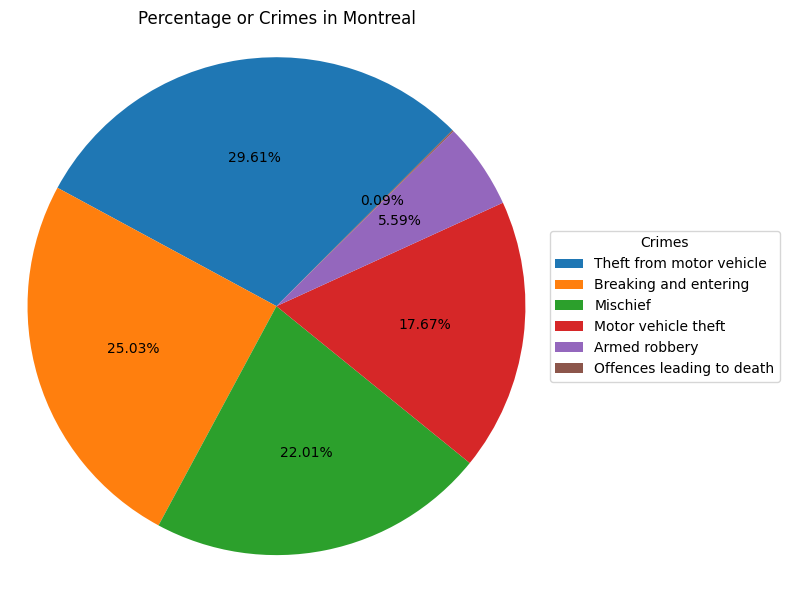

In [13]:
conteo_crimenes = df['Crime'].value_counts()

plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    conteo_crimenes,
    labels=None,
    startangle=45,
    autopct='%2.2f%%'
)

# Agregar leyenda aparte
plt.legend(wedges, conteo_crimenes.index, title="Crimes", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Percentage or Crimes in Montreal')
plt.axis('equal')  # Circulo proporcional

plt.tight_layout()
plt.show()

# What part of the day did most crimes occur

In [14]:
shift_crimes = df['Shift'].value_counts()
print(shift_crimes)

Shift
day         124382
afternon     81612
night        38123
Name: count, dtype: int64


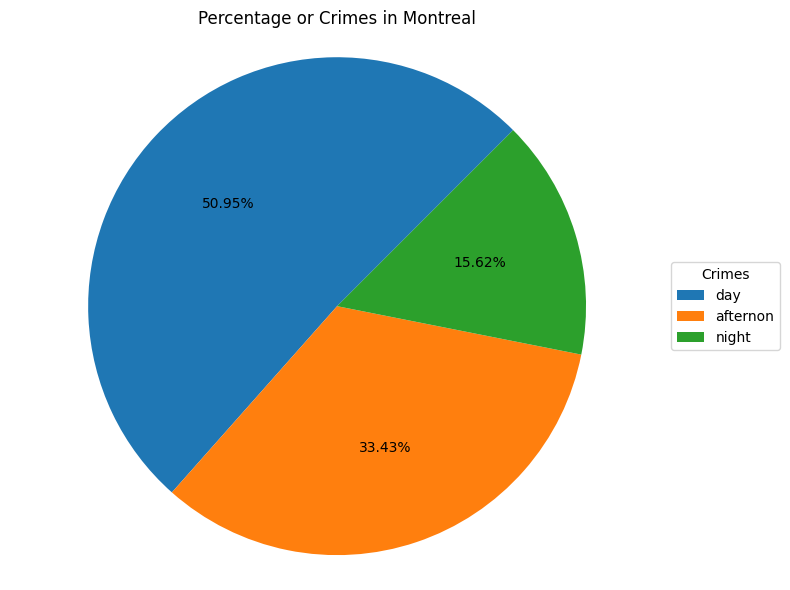

In [15]:
conteo_crimenes = df['Shift'].value_counts()

plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    conteo_crimenes,
    labels=None,
    startangle=45,
    autopct='%2.2f%%'
)

# Agregar leyenda aparte
plt.legend(wedges, conteo_crimenes.index, title="Crimes", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Percentage or Crimes in Montreal')
plt.axis('equal')  # Circulo proporcional

plt.tight_layout()
plt.show()

# Whicht Top 5 precincts got the most complains

In [16]:
PDQ_active = df['Precinct'].value_counts().head(5)

In [17]:
PDQ_active

,count
Precinct,
38,17270
21,14326
20,13593
48,11795
39,11149


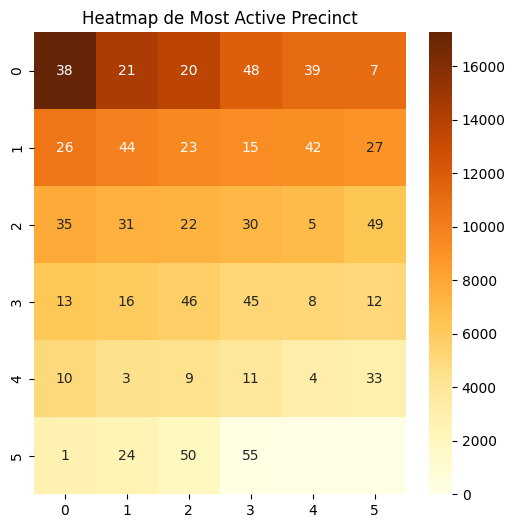

In [18]:
PDQ_active = df['Precinct'].value_counts()

values = PDQ_active.values
labels = PDQ_active.index

num_precincts = len(values)
cols = math.ceil(math.sqrt(num_precincts))
rows = math.ceil(num_precincts / cols)

# Rellenar con ceros para completar la matriz
fill_size = rows * cols - num_precincts
values_padded = np.append(values, [0]*fill_size)
labels_padded = list(labels) + [""] * fill_size

# Matriz y DataFrame
matrix = values_padded.reshape(rows, cols)
label_matrix = np.array(labels_padded).reshape(rows, cols)
heatmap_df = pd.DataFrame(matrix, columns=[f"{label}" for label in label_matrix[0]])

plt.figure(figsize=(cols, rows))
sns.heatmap(matrix.reshape(rows, cols), annot=label_matrix, fmt='', cmap="YlOrBr", cbar=True)
plt.title("Heatmap de Most Active Precinct")
plt.show()


# Which are the tops 3 Pqd that got least complains

In [19]:
PDQ_inactive = df['Precinct'].value_counts().tail(3)
PDQ_inactive

,count
Precinct,
24,2532
50,1950
55,90


# Which neighborhood has the most cases of murder

In [20]:
gdf_pdq = gpd.read_file('/content/drive/MyDrive/Notebooks/DB/Crimenes/limitespdq.geojson',encoding='ISO-8859-1')
gdf_pdq.head()

,PDQ,NOM_PDQ,geometry
0,1,PDQ-1,"MULTIPOLYGON (((-73.8405 45.4569, -73.8422 45...."
1,3,PDQ-3,"MULTIPOLYGON (((-73.9397 45.4701, -73.9398 45...."
2,4,PDQ-4,"MULTIPOLYGON (((-73.8159 45.5026, -73.8158 45...."
3,5,PDQ-5,"MULTIPOLYGON (((-73.7228 45.432, -73.7227 45.4..."
4,7,PDQ-7,"MULTIPOLYGON (((-73.6724 45.5325, -73.6715 45...."


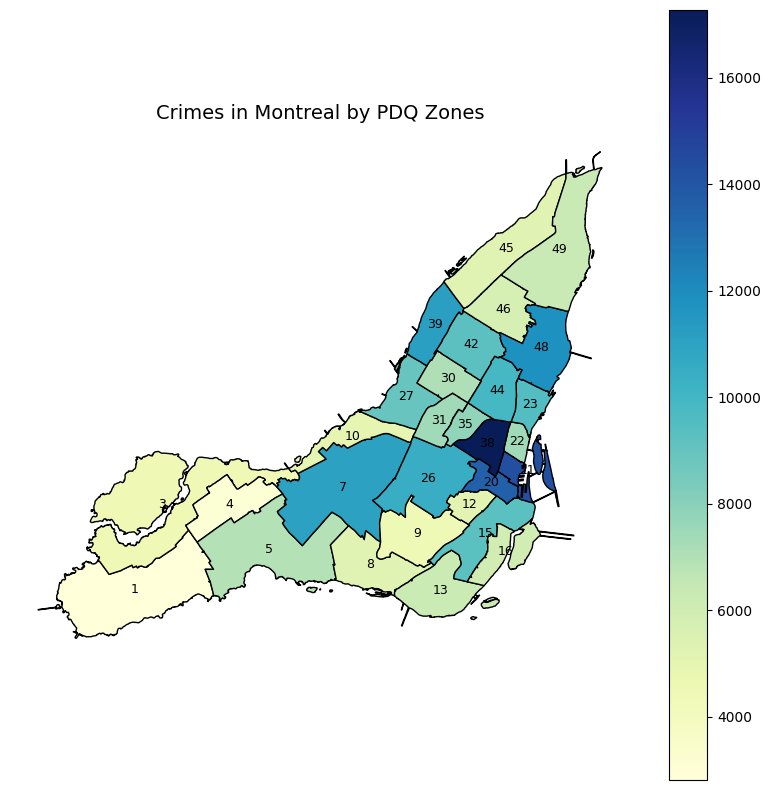

In [21]:
conteo_total = df['Precinct'].value_counts().reset_index()
conteo_total.columns = ['PDQ', 'Total_Crimes']

gdf_pdq['PDQ'] = gdf_pdq['PDQ'].astype(int)
conteo_total['PDQ'] = conteo_total['PDQ'].astype(int)

gdf_merged = gdf_pdq.merge(conteo_total, on='PDQ', how='left')
gdf_merged['Total_Crimes'] = gdf_merged['Total_Crimes'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_merged.plot(column='Total_Crimes', cmap='YlGnBu', legend=True, edgecolor='black', ax=ax)

for idx, row in gdf_merged.iterrows():
    centroid = row['geometry'].centroid
    plt.text(centroid.x, centroid.y, str(row['PDQ']), fontsize=9, ha='center', va='center', color='black')

plt.title('Crimes in Montreal by PDQ Zones', fontsize=14)
plt.axis('off')
plt.show()

In [22]:
conteo_total.head()

,PDQ,Total_Crimes
0,38,17270
1,21,14326
2,20,13593
3,48,11795
4,39,11149


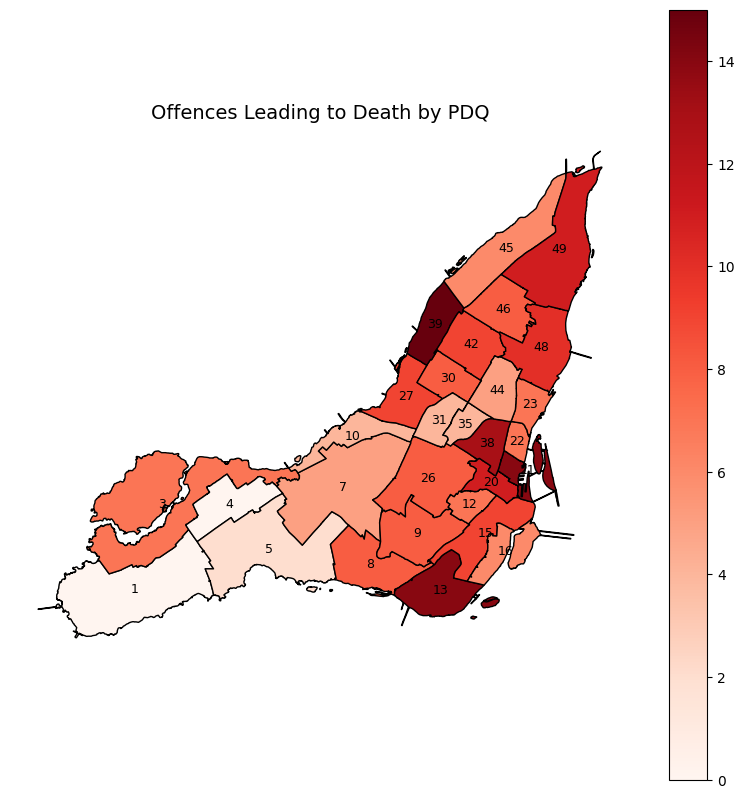

In [23]:
df_murder = df[df['Crime'] == 'Offences leading to death']

murders = df_murder['Precinct'].value_counts().reset_index()
murders.columns = ['PDQ', 'Murder_Count']

gdf_pdq['PDQ'] = gdf_pdq['PDQ'].astype(int)
murders['PDQ'] = murders['PDQ'].astype(int)
gdf_merged = gdf_pdq.merge(murders, on='PDQ', how='left')
gdf_merged['Murder_Count'] = gdf_merged['Murder_Count'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_merged.plot(column='Murder_Count', cmap='Reds', legend=True, edgecolor='black', ax=ax)

for idx, row in gdf_merged.iterrows():
    centroid = row['geometry'].centroid
    plt.text(centroid.x, centroid.y, str(row['PDQ']), fontsize=9, ha='center', va='center', color='black')

plt.title('Offences Leading to Death by PDQ', fontsize=14)
plt.axis('off')
plt.show()


In [24]:
murders.head()

,PDQ,Murder_Count
0,39,15
1,13,14
2,21,14
3,38,13
4,20,11
